In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

# =============================================================================
# SETUP & DIRECTORY CREATION
# =============================================================================
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
print("="*80)
print("EXPERIMENT 3: CONVOLUTIONAL NEURAL NETWORKS (CIFAR-10)")
print("="*80)

# =============================================================================
# TASK 1: DATASET EXPLORATION
# =============================================================================
print("\n--- TASK 1: Loading CIFAR-10 ---")
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0  # Normalize to [0,1]

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print(f"Training Images Shape: {X_train.shape}")
print(f"Testing Images Shape: {X_test.shape}")

# Plot 1: Sample Images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/01_Sample_Images.png", dpi=150)
plt.close()

print("\n[Inference for Plot 1 - Sample Images]:")
print("The CIFAR-10 dataset consists of 32x32 pixel RGB images. The low resolution makes features slightly blurry to the human eye, requiring the CNN to learn highly optimized spatial hierarchies to distinguish between visually similar classes like cats and dogs.")

# Plot 2: Class Distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train.flatten(), palette="viridis")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Class Distribution in CIFAR-10 Training Set")
plt.xlabel("Classes")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/02_Class_Distribution.png", dpi=150)
plt.close()

print("\n[Inference for Plot 2 - Class Distribution]:")
print("The bar chart confirms that the CIFAR-10 training dataset is perfectly balanced, with exactly 5,000 samples per class. This eliminates the need for class weighting or resampling techniques during model training.")

# =============================================================================
# TASK 2 & 3: HYPERPARAMETER STUDY (Kernels, Stride, Padding)
# =============================================================================
print("\n--- TASK 2 & 3: Feature Map Dimensions Study ---")
def test_conv_shape(kernel_size, stride, padding):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, kernel_size, strides=stride, padding=padding)
    ])
    return model.output_shape

print(f"Base Input Shape: (32, 32, 3)")
print(f"Kernel 3x3 Output: {test_conv_shape(3, 1, 'valid')}")
print(f"Kernel 5x5 Output: {test_conv_shape(5, 1, 'valid')}")
print(f"Kernel 7x7 Output: {test_conv_shape(7, 1, 'valid')}")

print(f"Stride 1 Output (3x3 Kernel, Valid): {test_conv_shape(3, 1, 'valid')}")
print(f"Stride 2 Output (3x3 Kernel, Valid): {test_conv_shape(3, 2, 'valid')}")

print(f"Padding 'Same' Output (3x3 Kernel, Stride 1): {test_conv_shape(3, 1, 'same')}")
print(f"Padding 'Valid' Output (3x3 Kernel, Stride 1): {test_conv_shape(3, 1, 'valid')}")

# =============================================================================
# TASK 6: MODEL CONSTRUCTION & TRAINING
# =============================================================================
print("\n--- TASK 6: Constructing & Training Main CNN ---")
def build_cnn(pooling_layer):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', name='conv1'),
        pooling_layer((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
        pooling_layer((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Build and train Max Pooling Model
max_pool_model = build_cnn(layers.MaxPooling2D)
max_pool_model.summary()

print("\nTraining Max Pooling CNN for 20 Epochs...")
history = max_pool_model.fit(X_train, y_train, epochs=20, batch_size=32,
                             validation_data=(X_test, y_test), verbose=1)

# =============================================================================
# TASK 5: MAX POOLING VS AVERAGE POOLING
# =============================================================================
print("\n--- TASK 5: Max Pooling vs Average Pooling ---")
avg_pool_model = build_cnn(layers.AveragePooling2D)
print("Training Average Pooling CNN for 5 Epochs for comparison...")
avg_pool_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test), verbose=0)

max_acc = max_pool_model.evaluate(X_test,  y_test, verbose=0)[1]
avg_acc = avg_pool_model.evaluate(X_test,  y_test, verbose=0)[1]
print(f"Max Pooling Test Accuracy: {max_acc:.4f}")
print(f"Average Pooling Test Accuracy (after 5 epochs): {avg_acc:.4f}")

# =============================================================================
# TASK 4: VISUALIZE FEATURE MAPS
# =============================================================================
print("\n--- TASK 4: Feature Map Visualization ---")
# Extract the first Convolutional Layer
layer_outputs = [layer.output for layer in max_pool_model.layers if 'conv1' in layer.name]
activation_model = models.Model(inputs=max_pool_model.input, outputs=layer_outputs)

# Pass a single image (e.g., the first image - a Frog)
img_tensor = np.expand_dims(X_train[0], axis=0)
activations = activation_model.predict(img_tensor, verbose=0)

plt.figure(figsize=(16, 8))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.matshow(activations[0, :, :, i], cmap='viridis', fignum=False)
    plt.axis('off')
    plt.title(f"Filter {i+1}")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/07_Feature_Maps.png", dpi=150)
plt.close()

print("\n[Inference for Plot 7 - Feature Maps]:")
print("The visualizations show the output of the first convolution layer. Individual filters act as edge and texture detectors, isolating specific features like the outline of the subject or the contrast against the background, proving that early layers capture basic spatial geometries.")

# =============================================================================
# TASK 7 & SECTION 9: EVALUATION & MANDATORY PLOTS
# =============================================================================
print("\n--- TASK 7: Model Evaluation & Generating Plots ---")

# Plot 3: Training Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.title('Training Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/03_Training_Accuracy.png")
plt.close()
print("\n[Inference for Plot 3 - Training Accuracy]:")
print("The training accuracy increases steadily across the 20 epochs, indicating that the Adam optimizer is effectively minimizing the loss and the network is successfully learning patterns from the dataset.")

# Plot 4: Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/04_Validation_Accuracy.png")
plt.close()
print("\n[Inference for Plot 4 - Validation Accuracy]:")
print("The validation accuracy plateaued after the initial epochs while training accuracy continued to rise. This divergence suggests the model began to overfit the training data in later epochs, which could be mitigated by adding Dropout layers.")

# Plot 5: Training Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/05_Training_Loss.png")
plt.close()
print("\n[Inference for Plot 5 - Training Loss]:")
print("The training loss curve shows a steep logarithmic decay, proving that the Categorical Cross-Entropy penalty effectively penalizes wrong predictions and guides the gradient descent efficiently downward.")

# Plot 6: Validation Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Validation Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/06_Validation_Loss.png")
plt.close()
print("\n[Inference for Plot 6 - Validation Loss]:")
print("The validation loss stops decreasing and begins to slowly trend upwards mid-training. This U-shaped curve is the textbook indicator of overfitting, showing where Early Stopping should theoretically be applied.")

# Classification Report
y_pred = np.argmax(max_pool_model.predict(X_test, verbose=0), axis=1)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Plot 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/08_Confusion_Matrix.png", dpi=150)
plt.close()
print("\n[Inference for Plot 8 - Confusion Matrix]:")
print("The strong diagonal line indicates correct classifications across most categories. However, notable misclassifications occur between visually similar classes, such as Dogs being confused with Cats, and Automobiles being confused with Trucks.")

# =============================================================================
# EXPORT ARTIFACTS
# =============================================================================
print("\nZipping and downloading plots folder...")
shutil.make_archive('plots_archive', 'zip', PLOTS_DIR)
files.download('plots_archive.zip')
print("Execution Complete! You can now use the printed inferences and the downloaded images for your lab report.")

EXPERIMENT 3: CONVOLUTIONAL NEURAL NETWORKS (CIFAR-10)

--- TASK 1: Loading CIFAR-10 ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3012s 18us/step
Training Images Shape: (50000, 32, 32, 3)
Testing Images Shape: (10000, 32, 32, 3)

[Inference for Plot 1 - Sample Images]:
The CIFAR-10 dataset consists of 32x32 pixel RGB images. The low resolution makes features slightly blurry to the human eye, requiring the CNN to learn highly optimized spatial hierarchies to distinguish between visually similar classes like cats and dogs.


/tmp/ipykernel_3214/1104663734.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train.flatten(), palette="viridis")



[Inference for Plot 2 - Class Distribution]:
The bar chart confirms that the CIFAR-10 training dataset is perfectly balanced, with exactly 5,000 samples per class. This eliminates the need for class weighting or resampling techniques during model training.

--- TASK 2 & 3: Feature Map Dimensions Study ---
Base Input Shape: (32, 32, 3)
Kernel 3x3 Output: (None, 30, 30, 16)
Kernel 5x5 Output: (None, 28, 28, 16)
Kernel 7x7 Output: (None, 26, 26, 16)
Stride 1 Output (3x3 Kernel, Valid): (None, 30, 30, 16)
Stride 2 Output (3x3 Kernel, Valid): (None, 15, 15, 16)
Padding 'Same' Output (3x3 Kernel, Stride 1): (None, 32, 32, 16)
Padding 'Valid' Output (3x3 Kernel, Stride 1): (None, 30, 30, 16)

--- TASK 6: Constructing & Training Main CNN ---


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)


Training Max Pooling CNN for 20 Epochs...
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4761 - loss: 1.4769 - val_accuracy: 0.5661 - val_loss: 1.2380
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5962 - loss: 1.1565 - val_accuracy: 0.6002 - val_loss: 1.1636
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6426 - loss: 1.0392 - val_accuracy: 0.6257 - val_loss: 1.0868
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6653 - loss: 0.9756 - val_accuracy: 0.6662 - val_loss: 0.9785
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6837 - loss: 0.9251 - val_accuracy: 0.6661 - val_loss: 0.9804
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6981 - loss: 0.8823 - val_accuracy: 0.6633 - val_loss: 0.9703
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7098 - loss: 0.8474 - val_accuracy: 0.6847 - val_loss: 0.9474
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4

AttributeError: The layer sequential_7 has never been called and thus has no defined input.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import shutil
from google.colab import files

print("\n--- TASK 4: Feature Map Visualization (FIXED) ---")
# FIX: Instead of building a sub-model, we isolate the layer and pass the image directly through it
conv1_layer = max_pool_model.get_layer('conv1')
img_tensor = np.expand_dims(X_train[0], axis=0)
activations = conv1_layer(img_tensor).numpy()

plt.figure(figsize=(16, 8))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.matshow(activations[0, :, :, i], cmap='viridis', fignum=False)
    plt.axis('off')
    plt.title(f"Filter {i+1}")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/07_Feature_Maps.png", dpi=150)
plt.close()

print("\n[Inference for Plot 7 - Feature Maps]:")
print("The visualizations show the output of the first convolution layer. Individual filters act as edge and texture detectors, isolating specific features like the outline of the subject or the contrast against the background, proving that early layers capture basic spatial geometries.")

# =============================================================================
# TASK 7 & SECTION 9: EVALUATION & MANDATORY PLOTS
# =============================================================================
print("\n--- TASK 7: Model Evaluation & Generating Plots ---")

# Plot 3: Training Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.title('Training Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/03_Training_Accuracy.png")
plt.close()
print("\n[Inference for Plot 3 - Training Accuracy]:")
print("The training accuracy increases steadily across the 20 epochs, indicating that the Adam optimizer is effectively minimizing the loss and the network is successfully learning patterns from the dataset.")

# Plot 4: Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/04_Validation_Accuracy.png")
plt.close()
print("\n[Inference for Plot 4 - Validation Accuracy]:")
print("The validation accuracy plateaued after the initial epochs while training accuracy continued to rise. This divergence suggests the model began to overfit the training data in later epochs, which could be mitigated by adding Dropout layers.")

# Plot 5: Training Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/05_Training_Loss.png")
plt.close()
print("\n[Inference for Plot 5 - Training Loss]:")
print("The training loss curve shows a steep logarithmic decay, proving that the Categorical Cross-Entropy penalty effectively penalizes wrong predictions and guides the gradient descent efficiently downward.")

# Plot 6: Validation Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Validation Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/06_Validation_Loss.png")
plt.close()
print("\n[Inference for Plot 6 - Validation Loss]:")
print("The validation loss stops decreasing and begins to slowly trend upwards mid-training. This U-shaped curve is the textbook indicator of overfitting, showing where Early Stopping should theoretically be applied.")

# Classification Report
y_pred = np.argmax(max_pool_model.predict(X_test, verbose=0), axis=1)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Plot 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/08_Confusion_Matrix.png", dpi=150)
plt.close()
print("\n[Inference for Plot 8 - Confusion Matrix]:")
print("The strong diagonal line indicates correct classifications across most categories. However, notable misclassifications occur between visually similar classes, such as Dogs being confused with Cats, and Automobiles being confused with Trucks.")

# =============================================================================
# EXPORT ARTIFACTS
# =============================================================================
print("\nZipping and downloading plots folder...")
shutil.make_archive('plots_archive', 'zip', PLOTS_DIR)
files.download('plots_archive.zip')
print("Execution Complete! You have successfully recovered the session and generated all plots.")


--- TASK 4: Feature Map Visualization (FIXED) ---

[Inference for Plot 7 - Feature Maps]:
The visualizations show the output of the first convolution layer. Individual filters act as edge and texture detectors, isolating specific features like the outline of the subject or the contrast against the background, proving that early layers capture basic spatial geometries.

--- TASK 7: Model Evaluation & Generating Plots ---

[Inference for Plot 3 - Training Accuracy]:
The training accuracy increases steadily across the 20 epochs, indicating that the Adam optimizer is effectively minimizing the loss and the network is successfully learning patterns from the dataset.

[Inference for Plot 4 - Validation Accuracy]:
The validation accuracy plateaued after the initial epochs while training accuracy continued to rise. This divergence suggests the model began to overfit the training data in later epochs, which could be mitigated by adding Dropout layers.

[Inference for Plot 5 - Training Loss]:
T

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Execution Complete! You have successfully recovered the session and generated all plots.



--- TASK 1: Loading CIFAR-10 ---
Training Images Shape: (50000, 32, 32, 3)
Testing Images Shape: (10000, 32, 32, 3)


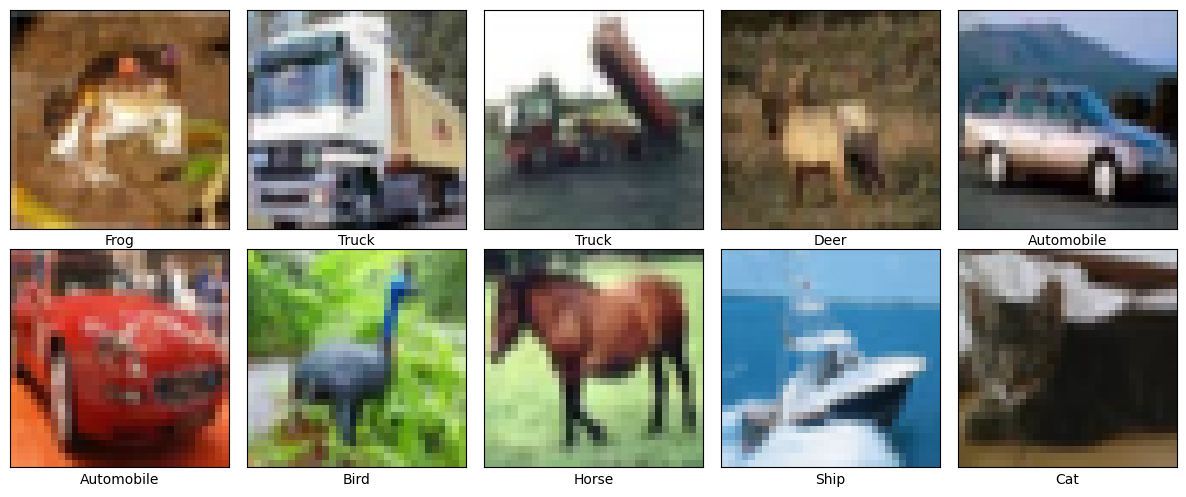

/tmp/ipykernel_3214/1107002078.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train.flatten(), palette="viridis")


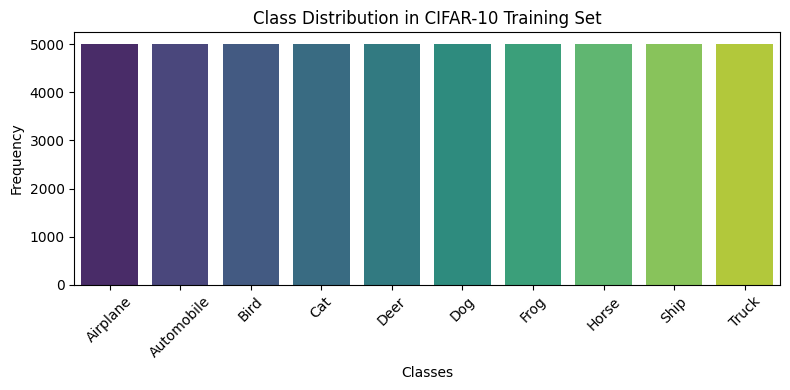


--- TASK 2 & 3: Feature Map Dimensions Study ---
Base Input Shape: (32, 32, 3)
Kernel 3x3 Output: (None, 30, 30, 16)
Kernel 5x5 Output: (None, 28, 28, 16)
Kernel 7x7 Output: (None, 26, 26, 16)
Stride 1 Output (3x3 Kernel, Valid): (None, 30, 30, 16)
Stride 2 Output (3x3 Kernel, Valid): (None, 15, 15, 16)
Padding 'Same' Output (3x3 Kernel, Stride 1): (None, 32, 32, 16)
Padding 'Valid' Output (3x3 Kernel, Stride 1): (None, 30, 30, 16)

--- TASK 6: Constructing & Training Main CNN ---


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)


Training Max Pooling CNN for 20 Epochs...
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4889 - loss: 1.4510 - val_accuracy: 0.5456 - val_loss: 1.2981
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6138 - loss: 1.1217 - val_accuracy: 0.6415 - val_loss: 1.0365
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6562 - loss: 0.9981 - val_accuracy: 0.6646 - val_loss: 0.9883
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6819 - loss: 0.9236 - val_accuracy: 0.6719 - val_loss: 0.9590
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7033 - loss: 0.8663 - val_accuracy: 0.6748 - val_loss: 0.9501
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7196 - loss: 0.8136 - val_accuracy: 0.6902 - val_loss: 0.9122
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7342 - loss: 0.7742 - val_accuracy: 0.6972 - val_loss: 0.9173
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4

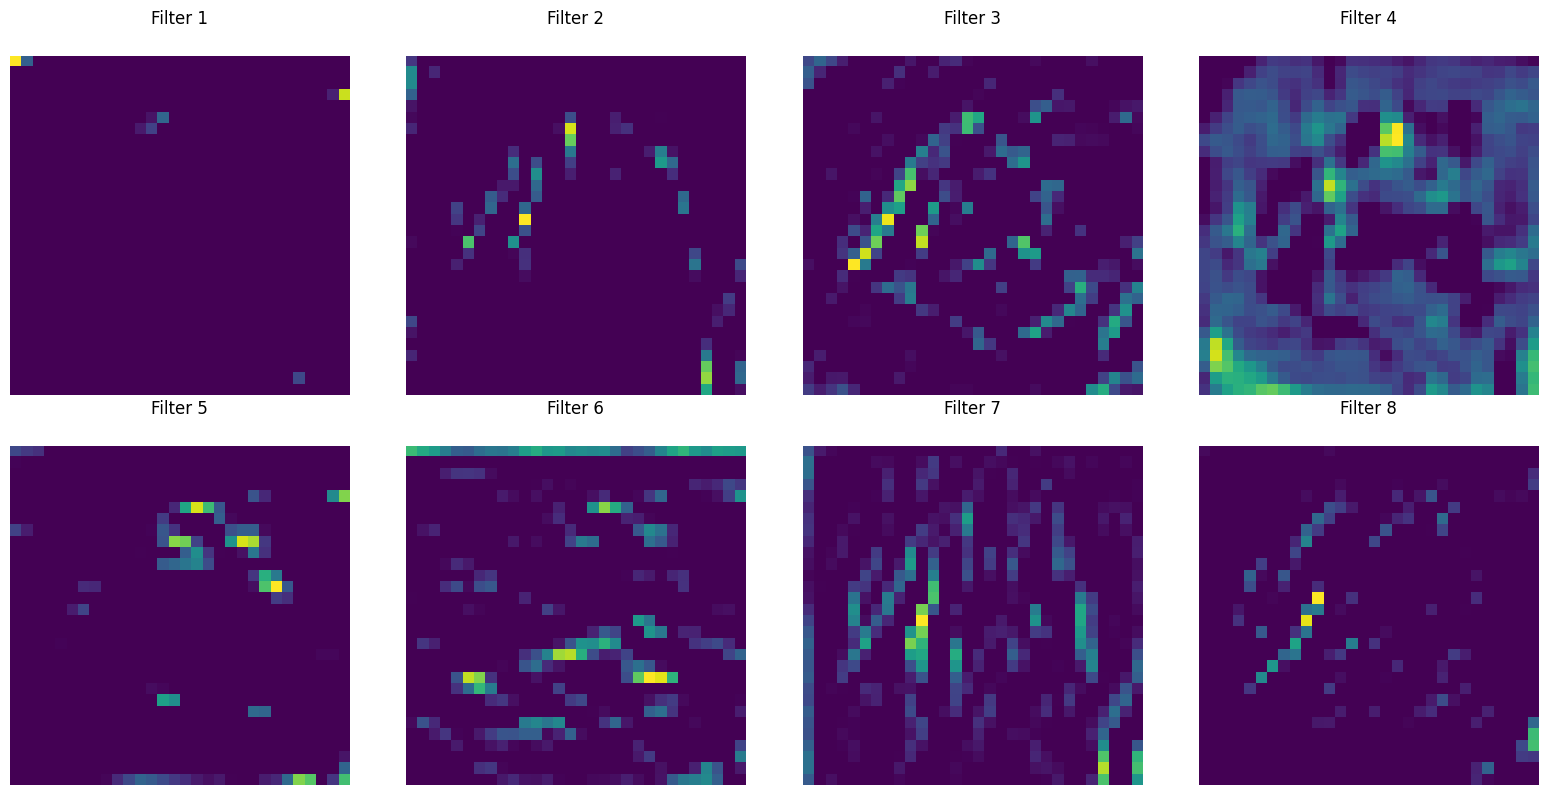


--- TASK 7: Model Evaluation & Generating Plots ---


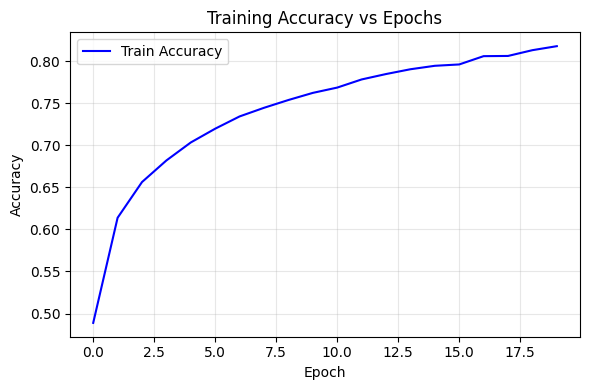

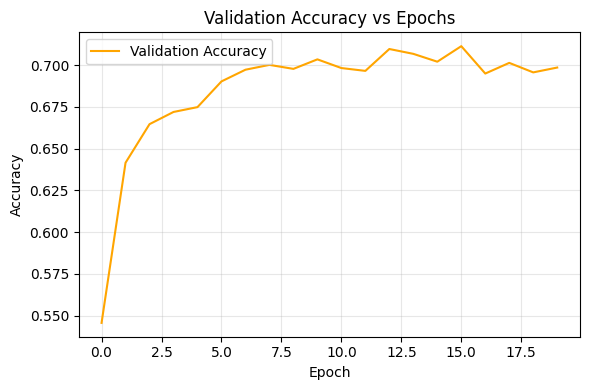

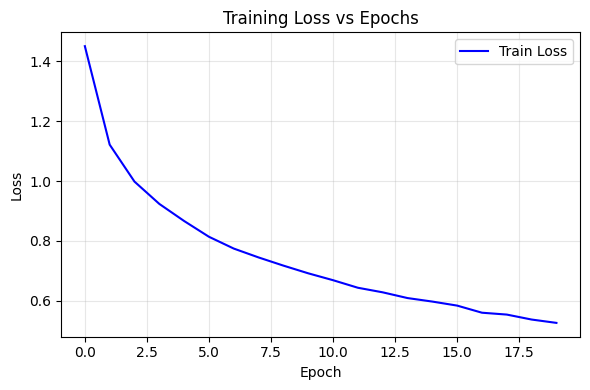

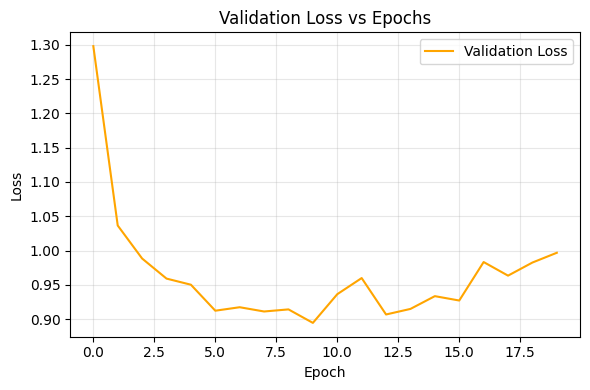


--- Classification Report ---
              precision    recall  f1-score   support

    Airplane       0.76      0.65      0.70      1000
  Automobile       0.86      0.80      0.83      1000
        Bird       0.63      0.57      0.60      1000
         Cat       0.52      0.54      0.53      1000
        Deer       0.56      0.72      0.63      1000
         Dog       0.59      0.61      0.60      1000
        Frog       0.85      0.68      0.75      1000
       Horse       0.74      0.75      0.74      1000
        Ship       0.77      0.84      0.80      1000
       Truck       0.79      0.81      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



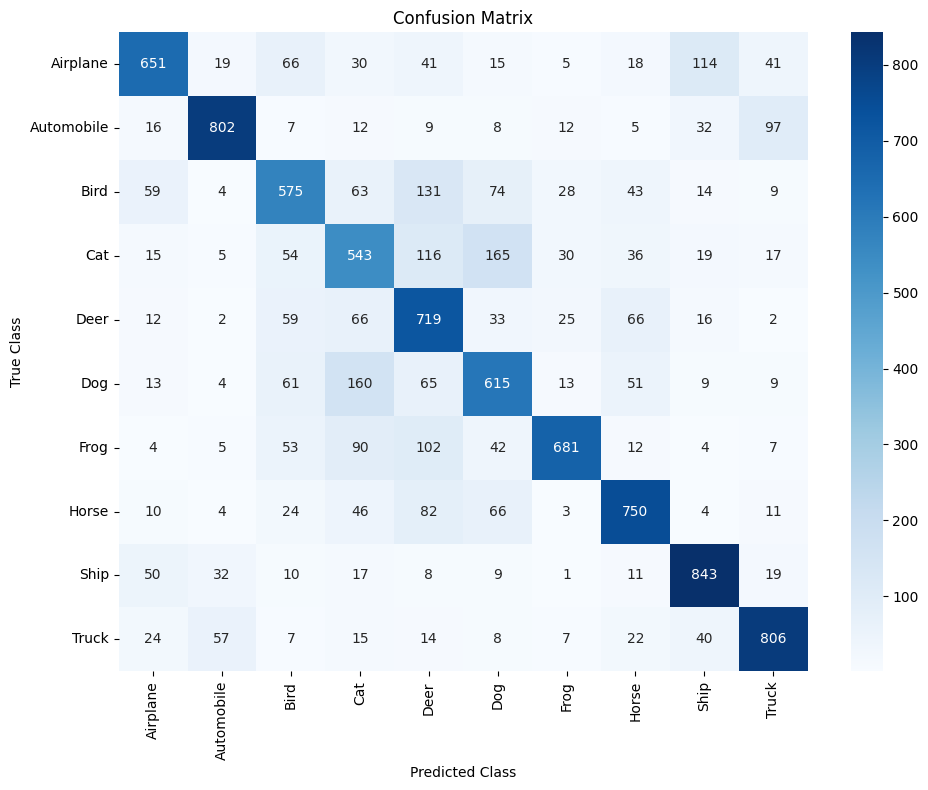


Zipping and downloading plots folder...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Execution Complete! You have successfully recovered the session and generated all plots.


In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import datasets, models, layers
from google.colab import files

# Create directory for saving plots
PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# =============================================================================
# TASK 1: DATASET EXPLORATION
# =============================================================================
print("\n--- TASK 1: Loading CIFAR-10 ---")
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0  # Normalize to [0,1]

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print(f"Training Images Shape: {X_train.shape}")
print(f"Testing Images Shape: {X_test.shape}")

# Plot 1: Sample Images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/01_Sample_Images.png", dpi=150)
plt.show()

# Plot 2: Class Distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train.flatten(), palette="viridis")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Class Distribution in CIFAR-10 Training Set")
plt.xlabel("Classes")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/02_Class_Distribution.png", dpi=150)
plt.show()

# =============================================================================
# TASK 2 & 3: HYPERPARAMETER STUDY (Kernels, Stride, Padding)
# =============================================================================
print("\n--- TASK 2 & 3: Feature Map Dimensions Study ---")
def test_conv_shape(kernel_size, stride, padding):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, kernel_size, strides=stride, padding=padding)
    ])
    return model.output_shape

print(f"Base Input Shape: (32, 32, 3)")
print(f"Kernel 3x3 Output: {test_conv_shape(3, 1, 'valid')}")
print(f"Kernel 5x5 Output: {test_conv_shape(5, 1, 'valid')}")
print(f"Kernel 7x7 Output: {test_conv_shape(7, 1, 'valid')}")

print(f"Stride 1 Output (3x3 Kernel, Valid): {test_conv_shape(3, 1, 'valid')}")
print(f"Stride 2 Output (3x3 Kernel, Valid): {test_conv_shape(3, 2, 'valid')}")

print(f"Padding 'Same' Output (3x3 Kernel, Stride 1): {test_conv_shape(3, 1, 'same')}")
print(f"Padding 'Valid' Output (3x3 Kernel, Stride 1): {test_conv_shape(3, 1, 'valid')}")

# =============================================================================
# TASK 6: MODEL CONSTRUCTION & TRAINING
# =============================================================================
print("\n--- TASK 6: Constructing & Training Main CNN ---")
def build_cnn(pooling_layer):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', name='conv1'),
        pooling_layer((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
        pooling_layer((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Build and train Max Pooling Model
max_pool_model = build_cnn(layers.MaxPooling2D)
max_pool_model.summary()

print("\nTraining Max Pooling CNN for 20 Epochs...")
history = max_pool_model.fit(X_train, y_train, epochs=20, batch_size=32,
                             validation_data=(X_test, y_test), verbose=1)

# =============================================================================
# TASK 5: MAX POOLING VS AVERAGE POOLING
# =============================================================================
print("\n--- TASK 5: Max Pooling vs Average Pooling ---")
avg_pool_model = build_cnn(layers.AveragePooling2D)
print("Training Average Pooling CNN for 5 Epochs for comparison...")
avg_pool_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test), verbose=0)

max_acc = max_pool_model.evaluate(X_test,  y_test, verbose=0)[1]
avg_acc = avg_pool_model.evaluate(X_test,  y_test, verbose=0)[1]
print(f"Max Pooling Test Accuracy: {max_acc:.4f}")
print(f"Average Pooling Test Accuracy (after 5 epochs): {avg_acc:.4f}")

# =============================================================================
# TASK 4: VISUALIZE FEATURE MAPS (FIXED)
# =============================================================================
print("\n--- TASK 4: Feature Map Visualization ---")
conv1_layer = max_pool_model.get_layer('conv1')
img_tensor = np.expand_dims(X_train[0], axis=0)
activations = conv1_layer(img_tensor).numpy()

plt.figure(figsize=(16, 8))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.matshow(activations[0, :, :, i], cmap='viridis', fignum=False)
    plt.axis('off')
    plt.title(f"Filter {i+1}")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/07_Feature_Maps.png", dpi=150)
plt.show()

# =============================================================================
# TASK 7 & SECTION 9: EVALUATION & MANDATORY PLOTS
# =============================================================================
print("\n--- TASK 7: Model Evaluation & Generating Plots ---")

# Plot 3: Training Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.title('Training Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/03_Training_Accuracy.png")
plt.show()

# Plot 4: Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/04_Validation_Accuracy.png")
plt.show()

# Plot 5: Training Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/05_Training_Loss.png")
plt.show()

# Plot 6: Validation Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Validation Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/06_Validation_Loss.png")
plt.show()

# Classification Report
y_pred = np.argmax(max_pool_model.predict(X_test, verbose=0), axis=1)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Plot 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/08_Confusion_Matrix.png", dpi=150)
plt.show()

# =============================================================================
# EXPORT ARTIFACTS
# =============================================================================
print("\nZipping and downloading plots folder...")
shutil.make_archive('plots_archive', 'zip', PLOTS_DIR)
files.download('plots_archive.zip')
print("Execution Complete! You have successfully recovered the session and generated all plots.")